## Customer Churn Prediction


        
	    Variable   	Discerption
  	    CustomerID	Unique customer ID
    	Churn	    Churn Flag
    	Tenure	    Tenure of customer in organization
    	PreferredLoginDevice	Preferred login device of customer
    	CityTier	    City tier
    	WarehouseToHome	    Distance in between warehouse to home of customer
    	PreferredPaymentMode	Preferred payment method of customer
    	Gender	    Gender of customer
    	HourSpendOnApp	    Number of hours spend on mobile application or website
    	NumberOfDeviceRegistered	Total number of deceives is registered on particular customer
    	PreferedOrderCat	Preferred order category of customer in last month
    	SatisfactionScore	Satisfactory score of customer on service
    	MaritalStatus	Marital status of customer
    	NumberOfAddress	Total number of added added on particular customer
    	Complain	Any complaint has been raised in last month
    	OrderAmountHikeFromlastYear	Percentage increases in order from last year
    	CouponUsed	Total number of coupon has been used in last month
    	OrderCount	Total number of orders has been places in last month
    	DaySinceLastOrder	Day Since last order by customer
    	CashbackAmount	Average cashback in last month

1. Business Training
2. Data Understanding
3.  Data cleaning _Preprocessing
    a. Drop useless columns
    b. Handle missing values properly
    c.encode
4. Feature Engineering
5. Model Strategy
6. Evaluation
7. Deployment _ MLOps


Raw Data
   ↓
Preprocessing Pipeline
   ↓
Feature Engineering
   ↓
Model Training
   ↓
MLflow Tracking
   ↓
Saved Model (.pkl)
   ↓
FastAPI Prediction API
   ↓
Docker Container
   ↓
GitHub Actions CI/CD
   ↓
Cloud Deployment
   ↓
Monitoring + Retraining

customer-churn-mlops/
│
├── data/
│   ├── raw/
│   └── processed/
│
├── notebooks/
│   └── churn_eda.ipynb
│
├── src/
│   ├── data_ingestion.py
│   ├── preprocessing.py
│   ├── feature_engineering.py
│   ├── train.py
│   ├── evaluate.py
│   └── predict.py
│
├── models/
│   └── churn_model.pkl
│
├── app/
│   └── main.py
│
├── tests/
│   └── test_api.py
│
├── .github/workflows/
│   └── ci.yml
│
├── Dockerfile
├── requirements.txt
└── README.md

In [44]:
# pip install pandas scikit-learn

In [79]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [46]:
# pip install openpyxl

In [47]:

folder="/Users/deepaksivas/Documents/GitHub/Retail-data-science-portfolio-/churn/data"
filename="E Commerce Dataset.xlsx"
file_path=os.path.join(folder, filename)
data=pd.read_excel(file_path,sheet_name='E Comm')

In [48]:
data.head(10)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


In [49]:
data.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='str')

### Pre-Processing

In [51]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [52]:
data.nunique().sort_values(ascending=False)

CustomerID                     5630
CashbackAmount                 2586
Tenure                           36
WarehouseToHome                  34
DaySinceLastOrder                22
CouponUsed                       17
OrderCount                       16
OrderAmountHikeFromlastYear      16
NumberOfAddress                  15
PreferredPaymentMode              7
PreferedOrderCat                  6
NumberOfDeviceRegistered          6
HourSpendOnApp                    6
SatisfactionScore                 5
PreferredLoginDevice              3
MaritalStatus                     3
CityTier                          3
Churn                             2
Complain                          2
Gender                            2
dtype: int64

1. Number of classes are 2 
2. Columns=["PreferredPaymentMode","PreferedOrderCat","NumberOfDeviceRegistered","HourSpendOnApp","SatisfactionScore","PreferredLoginDevice","MaritalStatus","CityTier","Complain","Gender"]

In [69]:
# drop uniques id column
data=data.drop('CustomerID',axis=1)

KeyError: "['CustomerID'] not found in axis"

In [54]:
for col in data.columns:
    print(f"{col}: {data[col].nunique(),data[col].unique()}")
# data.describe()


Churn: (2, array([1, 0]))
Tenure: (36, array([ 4., nan,  0., 13., 11.,  9., 19., 20., 14.,  8., 18.,  5.,  2.,
       30.,  1., 23.,  3., 29.,  6., 26., 28.,  7., 24., 25., 10., 15.,
       22., 27., 16., 12., 21., 17., 50., 60., 31., 51., 61.]))
PreferredLoginDevice: (3, <StringArray>
['Mobile Phone', 'Phone', 'Computer']
Length: 3, dtype: str)
CityTier: (3, array([3, 1, 2]))
WarehouseToHome: (34, array([  6.,   8.,  30.,  15.,  12.,  22.,  11.,   9.,  31.,  18.,  13.,
        20.,  29.,  28.,  26.,  14.,  nan,  10.,  27.,  17.,  23.,  33.,
        19.,  35.,  24.,  16.,  25.,  32.,  34.,   5.,  21., 126.,   7.,
        36., 127.]))
PreferredPaymentMode: (7, <StringArray>
['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD',
 'Credit Card']
Length: 7, dtype: str)
Gender: (2, <StringArray>
['Female', 'Male']
Length: 2, dtype: str)
HourSpendOnApp: (6, array([ 3.,  2., nan,  1.,  0.,  4.,  5.]))
NumberOfDeviceRegistered: (6, array([3, 4, 5, 2, 1, 6]))
PreferedOrderCat: (6, <

In [55]:
Columns_cat=["PreferredPaymentMode","PreferedOrderCat","NumberOfDeviceRegistered","HourSpendOnApp","SatisfactionScore","PreferredLoginDevice","MaritalStatus","CityTier","Complain","Gender"]

In [70]:
for col in Columns_cat:
    print(f"{col}: {data[col].nunique(),data[col].unique()}")

PreferredPaymentMode: (7, ['Debit Card', 'UPI', 'Cash on Delivery', 'CC', 'COD', 'Credit Card', 'E wallet']
Categories (7, str): ['CC', 'COD', 'Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI'])
PreferedOrderCat: (6, ['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']
Categories (6, str): ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others'])
NumberOfDeviceRegistered: (6, array([3, 4, 5, 2, 1, 6]))
HourSpendOnApp: (5, array([3., 2., 1., 4., 5.]))
SatisfactionScore: (5, array([2, 3, 5, 4, 1]))
PreferredLoginDevice: (3, ['Mobile Phone', 'Phone', 'Computer']
Categories (3, str): ['Computer', 'Mobile Phone', 'Phone'])
MaritalStatus: (3, ['Single', 'Divorced', 'Married']
Categories (3, str): ['Divorced', 'Married', 'Single'])
CityTier: (3, array([3, 1, 2]))
Complain: (2, array([1, 0]))
Gender: (2, ['Female', 'Male']
Categories (2, str): ['Female', 'Male'])


Axes(0.125,0.11;0.775x0.77)


<Axes: xlabel='Churn'>

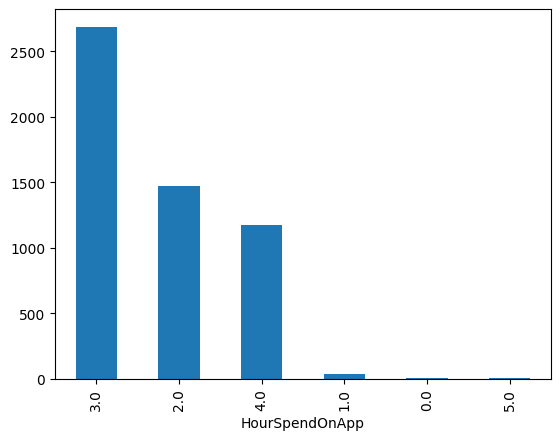

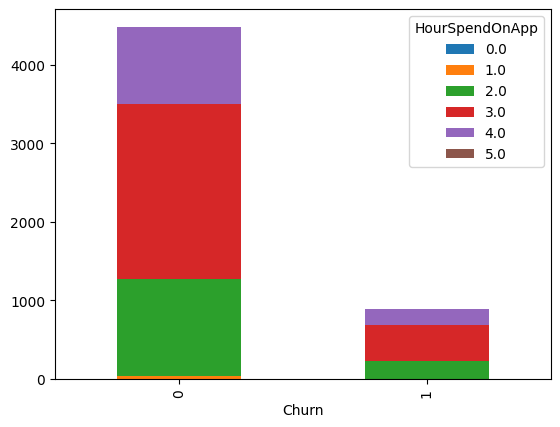

In [ ]:
# HourSpendOnApp

data["HourSpendOnApp"].value_counts()
data["HourSpendOnApp"].unique()
print(data["HourSpendOnApp"].value_counts().plot(kind="bar"))
data['HourSpendOnApp'].groupby(data['Churn']).value_counts().unstack().plot(kind='bar', stacked=True)


In [76]:
str_col=['PreferredPaymentMode','PreferedOrderCat','PreferredLoginDevice','MaritalStatus','Gender']
for col in str_col:
    print(data[col].astype('category'))

0        Debit Card
1               UPI
2        Debit Card
3        Debit Card
5        Debit Card
           ...     
5625    Credit Card
5626    Credit Card
5627     Debit Card
5628    Credit Card
5629    Credit Card
Name: PreferredPaymentMode, Length: 5372, dtype: category
Categories (7, str): ['CC', 'COD', 'Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']
0       Laptop & Accessory
1                   Mobile
2                   Mobile
3       Laptop & Accessory
5             Mobile Phone
               ...        
5625    Laptop & Accessory
5626               Fashion
5627    Laptop & Accessory
5628    Laptop & Accessory
5629    Laptop & Accessory
Name: PreferedOrderCat, Length: 5372, dtype: category
Categories (6, str): ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others']
0       Mobile Phone
1              Phone
2              Phone
3              Phone
5           Computer
            ...     
5625        Computer
5626    Mobile Phon

In [71]:
data

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
5,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90


In [59]:
data[str_col]=data[str_col].astype('category')

In [60]:
data.isnull().sum().sort_values(ascending=False)

DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
Churn                            0
MaritalStatus                    0
Complain                         0
NumberOfAddress                  0
PreferedOrderCat                 0
SatisfactionScore                0
NumberOfDeviceRegistered         0
Gender                           0
PreferredPaymentMode             0
CityTier                         0
PreferredLoginDevice             0
CashbackAmount                   0
dtype: int64

<Axes: xlabel='Complain'>

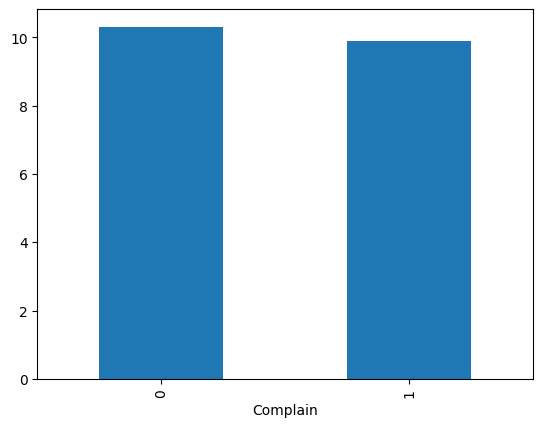

In [62]:
data.groupby("Complain")["Tenure"].mean()
data.groupby("Complain")["Tenure"].mean().plot(kind="bar")

### Unique numbers

In [81]:
data.isnull().sum().sort_values(ascending=False)

DaySinceLastOrder              306
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     257
CouponUsed                     256
WarehouseToHome                251
Churn                            0
MaritalStatus                    0
Complain                         0
NumberOfAddress                  0
PreferedOrderCat                 0
SatisfactionScore                0
NumberOfDeviceRegistered         0
HourSpendOnApp                   0
Gender                           0
PreferredPaymentMode             0
CityTier                         0
PreferredLoginDevice             0
CashbackAmount                   0
dtype: int64

In [73]:
data.head(5)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
5,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19


In [74]:
data.describe()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5372.000000,5108.000000,5372.000000,5121.000000,5372.000000,5372.000000,5372.000000,5372.000000,5372.000000,5107.000000,5116.000000,5115.000000,5066.000000,5372.000000
mean,0.165674,10.407204,1.664371,15.692443,2.933172,3.718354,3.070179,4.275130,0.285927,15.721167,1.790852,3.063343,4.635018,179.513124
std,0.371822,8.572398,0.919782,8.565563,0.718794,1.018254,1.381214,2.582951,0.451897,3.674180,1.899025,2.963257,3.662088,49.187977
min,0.000000,0.000000,1.000000,5.000000,1.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,3.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,147.690000
50%,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,165.375000
75%,0.000000,16.000000,3.000000,21.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,8.000000,199.422500
max,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


### Cleaning

In [77]:
Columns_cat

['PreferredPaymentMode',
 'PreferedOrderCat',
 'NumberOfDeviceRegistered',
 'HourSpendOnApp',
 'SatisfactionScore',
 'PreferredLoginDevice',
 'MaritalStatus',
 'CityTier',
 'Complain',
 'Gender']

In [78]:
data.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='str')

In [80]:
## Convert to categorical value
### Label encoding

col=['MaritalStatus','PreferedOrderCat','Gender','PreferredPaymentMode','PreferredLoginDevice']
le=LabelEncoder()
for i in col:
    data[i]=le.fit_transform(data[i])

data.head(5)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,1,3,6.0,4,0,3.0,3,2,2,2,9,1,11.0,1.0,1.0,5.0,159.93
1,1,NaN,2,1,8.0,6,1,3.0,4,3,3,2,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,2,1,30.0,4,1,2.0,4,3,3,2,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,2,3,15.0,4,1,2.0,4,2,5,2,8,0,23.0,0.0,1.0,3.0,134.07
5,1,0.0,0,1,22.0,4,0,3.0,5,4,5,2,2,1,22.0,4.0,6.0,7.0,139.19


DaySinceLastOrder              306
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     257
CouponUsed                     256
WarehouseToHome                251

In [ ]:
print(data[['OrderCount','Churn','SatisfactionScore']])

# display 'OrderCount','Churn','SatisfactionScore' if ordercount has only null values
data[['OrderCount','Churn','SatisfactionScore']][data['OrderCount'].isnull()]

In [86]:
data.describe()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5372.000000,5108.000000,5372.000000,5372.000000,5121.000000,5372.000000,5372.000000,5372.000000,5372.000000,5372.000000,5372.000000,5372.000000,5372.000000,5372.000000,5107.000000,5116.000000,5115.000000,5066.000000,5372.000000
mean,0.165674,10.407204,0.905808,1.664371,15.692443,3.575019,0.598660,2.933172,3.718354,2.343634,3.070179,1.168838,4.275130,0.285927,15.721167,1.790852,3.063343,4.635018,179.513124
std,0.371822,8.572398,0.690432,0.919782,8.565563,1.341985,0.490215,0.718794,1.018254,1.437693,1.381214,0.665374,2.582951,0.451897,3.674180,1.899025,2.963257,3.662088,49.187977
min,0.000000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,3.000000,0.000000,1.000000,9.000000,3.000000,0.000000,2.000000,3.000000,2.000000,2.000000,1.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,147.690000
50%,0.000000,9.000000,1.000000,1.000000,14.000000,4.000000,1.000000,3.000000,4.000000,2.000000,3.000000,1.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,165.375000
75%,0.000000,16.000000,1.000000,3.000000,21.000000,4.000000,1.000000,3.000000,4.000000,4.000000,4.000000,2.000000,6.000000,1.000000,18.000000,2.000000,3.000000,8.000000,199.422500
max,1.000000,61.000000,2.000000,3.000000,127.000000,6.000000,1.000000,5.000000,6.000000,5.000000,5.000000,2.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [92]:
print(data.info())
data.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
Index: 5372 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5372 non-null   int64  
 1   Tenure                       5108 non-null   float64
 2   PreferredLoginDevice         5372 non-null   int64  
 3   CityTier                     5372 non-null   int64  
 4   WarehouseToHome              5121 non-null   float64
 5   PreferredPaymentMode         5372 non-null   int64  
 6   Gender                       5372 non-null   int64  
 7   HourSpendOnApp               5372 non-null   float64
 8   NumberOfDeviceRegistered     5372 non-null   int64  
 9   PreferedOrderCat             5372 non-null   int64  
 10  SatisfactionScore            5372 non-null   int64  
 11  MaritalStatus                5372 non-null   int64  
 12  NumberOfAddress              5372 non-null   int64  
 13  Complain                     5372 

DaySinceLastOrder              306
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     257
CouponUsed                     256
WarehouseToHome                251
Churn                            0
MaritalStatus                    0
Complain                         0
NumberOfAddress                  0
PreferedOrderCat                 0
SatisfactionScore                0
NumberOfDeviceRegistered         0
HourSpendOnApp                   0
Gender                           0
PreferredPaymentMode             0
CityTier                         0
PreferredLoginDevice             0
CashbackAmount                   0
dtype: int64

#### Remove rows having value 0


In [67]:
data=data[(data['HourSpendOnApp'])!=0]

In [68]:
data['HourSpendOnApp'].value_counts()

HourSpendOnApp
3.0    2687
2.0    1471
4.0    1176
1.0      35
5.0       3
Name: count, dtype: int64

### Feature Engineering

1. Order Frequency
2. Complaint- Risk Customer
3. App engagement


### Modelling

### Train - test split


In [ ]:
X=data.drop(columns=["Churn"])
Y=data["Churn"]

### Evaluation

### Deployment